In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sb

In [2]:
df=pd.read_csv(r"C:\Users\USER\Downloads\DKHousingPricesSample100k.csv")

In [3]:
df.head()

,date,quarter,house_id,house_type,sales_type,year_build,purchase_price,%_change_between_offer_and_purchase,no_rooms,sqm,sqm_price,address,zip_code,city,area,region,nom_interest_rate%,dk_ann_infl_rate%,yield_on_mortgage_credit_bonds%
0,2024-10-24,2024Q4,16,Villa,regular_sale,1997,6500000,-3.0,5,142.0,45774.650,Spættevej 16,2680,Solrød Strand,"Capital, Copenhagen",Zealand,3.1,NaN,NaN
1,2024-10-24,2024Q4,13,Apartment,regular_sale,1885,3400000,0.0,2,46.0,73913.050,"Jakob Dannefærds Vej 10B, 4. th",1973,Frederiksberg C,"Capital, Copenhagen",Zealand,3.1,NaN,NaN
2,2024-10-23,2024Q4,60,Villa,regular_sale,1949,4550000,-4.0,4,112.0,40625.000,Vestre Plantagevej 3,2680,Solrød Strand,"Capital, Copenhagen",Zealand,3.1,NaN,NaN
3,2024-10-23,2024Q4,29,Villa,regular_sale,2001,1630000,-12.0,4,186.0,8763.440,Toftebjerg 3,4400,Kalundborg,Other islands,Zealand,3.1,NaN,NaN
4,2024-10-22,2024Q4,92,Apartment,regular_sale,1965,1975000,-10.0,3,82.0,24085.365,"Ryttergårdsvej 20, 1. 113",3520,Farum,North Zealand,Zealand,3.1,NaN,NaN


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 19 columns):
 #   Column                               Non-Null Count   Dtype  
---  ------                               --------------   -----  
 0   date                                 100000 non-null  object 
 1   quarter                              100000 non-null  object 
 2   house_id                             100000 non-null  int64  
 3   house_type                           100000 non-null  object 
 4   sales_type                           100000 non-null  object 
 5   year_build                           100000 non-null  int64  
 6   purchase_price                       100000 non-null  int64  
 7   %_change_between_offer_and_purchase  100000 non-null  float64
 8   no_rooms                             100000 non-null  int64  
 9   sqm                                  100000 non-null  float64
 10  sqm_price                            100000 non-null  float64
 11  address       

In [5]:
df.dtypes

date                                    object
quarter                                 object
house_id                                 int64
house_type                              object
sales_type                              object
year_build                               int64
purchase_price                           int64
%_change_between_offer_and_purchase    float64
no_rooms                                 int64
sqm                                    float64
sqm_price                              float64
address                                 object
zip_code                                 int64
city                                    object
area                                    object
region                                  object
nom_interest_rate%                     float64
dk_ann_infl_rate%                      float64
yield_on_mortgage_credit_bonds%        float64
dtype: object

In [6]:
df.duplicated().sum()

0

In [7]:
missing=df.isna().sum()
missing

date                                    0
quarter                                 0
house_id                                0
house_type                              0
sales_type                              0
year_build                              0
purchase_price                          0
%_change_between_offer_and_purchase     0
no_rooms                                0
sqm                                     0
sqm_price                               0
address                                 0
zip_code                                0
city                                   11
area                                    0
region                                  0
nom_interest_rate%                      0
dk_ann_infl_rate%                      77
yield_on_mortgage_credit_bonds%        77
dtype: int64

In [8]:
df.isna().sum().sum()

165

In [9]:
missing_percent=(missing/len(df))*100
missing_percent

date                                   0.000
quarter                                0.000
house_id                               0.000
house_type                             0.000
sales_type                             0.000
year_build                             0.000
purchase_price                         0.000
%_change_between_offer_and_purchase    0.000
no_rooms                               0.000
sqm                                    0.000
sqm_price                              0.000
address                                0.000
zip_code                               0.000
city                                   0.011
area                                   0.000
region                                 0.000
nom_interest_rate%                     0.000
dk_ann_infl_rate%                      0.077
yield_on_mortgage_credit_bonds%        0.077
dtype: float64

In [10]:
summary=pd.DataFrame({
    "Data Type": df.dtypes,
    "Missing Values": missing,
    "Missing Percentage": missing_percent
})
summary.sort_values("Missing Percentage", ascending=False)

,Data Type,Missing Values,Missing Percentage
yield_on_mortgage_credit_bonds%,float64,77,0.077
dk_ann_infl_rate%,float64,77,0.077
city,object,11,0.011
sqm_price,float64,0,0.000
nom_interest_rate%,float64,0,0.000
region,object,0,0.000
area,object,0,0.000
zip_code,int64,0,0.000
address,object,0,0.000
date,object,0,0.000


In [11]:
pd.set_option('display.float_format','{:,.2f}'.format)

In [12]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
house_id,"100,000.00","753,136.43","434,890.17",13.00,"377,072.25","751,103.50","1,128,904.25","1,507,901.00"
year_build,"100,000.00","1,955.08",45.70,"1,000.00","1,931.00","1,966.00","1,980.00","2,024.00"
purchase_price,"100,000.00","1,925,992.20","1,777,832.20","250,200.00","800,000.00","1,400,000.00","2,450,000.00","45,955,000.00"
%_change_between_offer_and_purchase,"100,000.00",-2.08,4.85,-49.00,-3.00,0.00,0.00,49.00
no_rooms,"100,000.00",4.38,1.66,1.00,3.00,4.00,5.00,15.00
sqm,"100,000.00",129.39,57.17,26.00,89.00,123.00,160.00,984.00
sqm_price,"100,000.00","16,406.65","13,655.18",374.55,"6,792.94","12,070.71","21,343.20","75,000.00"
zip_code,"100,000.00","5,951.61","2,369.94","1,051.00","4,000.00","5,970.00","8,250.00","9,990.00"
nom_interest_rate%,"100,000.00",1.68,2.05,0.00,0.00,0.75,3.25,9.50
dk_ann_infl_rate%,"99,923.00",1.93,1.64,0.25,0.79,1.85,2.34,7.70


In [13]:
numeric_cols=df.select_dtypes(include=np.number).columns
for col in numeric_cols:
    df[col].fillna(df[col].median(), inplace=True)
    
categorical_cols=df.select_dtypes(include='object').columns
for col in categorical_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

df['date']=pd.to_datetime(df['date'])

df['quarter']=df['quarter'].astype('category')

C:\Users\USER\AppData\Local\Temp\ipykernel_1288\2928720928.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)
C:\Users\USER\AppData\Local\Temp\ipykernel_1288\2928720928.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, 

In [14]:
columns =['purchase_price', 'sqm', 'sqm_price']

for col in columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1
    lower = Q1 - 1.5*IQR
    upper = Q3 + 1.5*IQR

    outliers=df[(df[col]<lower)|(df[col]>upper)]
    print(col)
    print('Number of outliers before handling:', len(outliers))

purchase_price
Number of outliers before handling: 5576
sqm
Number of outliers before handling: 2099
sqm_price
Number of outliers before handling: 6086


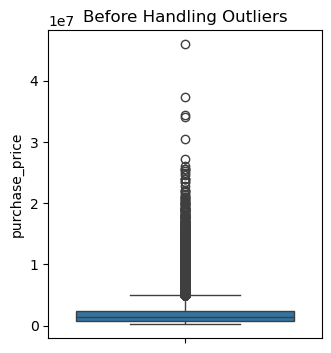

In [15]:
plt.figure(figsize=(12,4))
plt.subplot(1,3,1)
sb.boxplot(y=df['purchase_price'])
plt.title('Before Handling Outliers')
plt.show()

In [16]:
for col in columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1
    lower = Q1 - 1.5*IQR
    upper = Q3 + 1.5*IQR

    df[col] = np.clip(df[col], lower, upper)

In [17]:
columns =['purchase_price', 'sqm', 'sqm_price']

for col in columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1
    lower = Q1 - 1.5*IQR
    upper = Q3 + 1.5*IQR

    outliers=df[(df[col]<lower)|(df[col]>upper)]
    print(col)
    print('Number of outliers after Capping:', len(outliers))

purchase_price
Number of outliers after Capping: 0
sqm
Number of outliers after Capping: 0
sqm_price
Number of outliers after Capping: 0


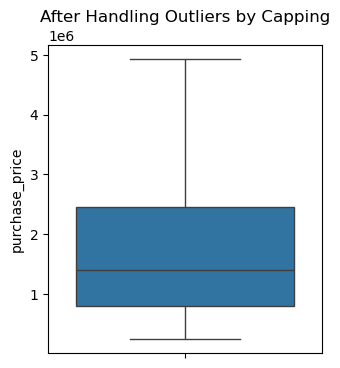

In [18]:
plt.figure(figsize=(12,4))
plt.subplot(1,3,1)
sb.boxplot(y=df['purchase_price'])
plt.title('After Handling Outliers by Capping')
plt.show()

In [19]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
date,100000,2012-10-28 09:36:46.656000,1992-01-05 00:00:00,2005-09-21 00:00:00,2015-03-31 00:00:00,2020-09-24 00:00:00,2024-10-24 00:00:00,NaN
house_id,"100,000.00","753,136.43",13.00,"377,072.25","751,103.50","1,128,904.25","1,507,901.00","434,890.17"
year_build,"100,000.00","1,955.08","1,000.00","1,931.00","1,966.00","1,980.00","2,024.00",45.70
purchase_price,"100,000.00","1,799,040.58","250,200.00","800,000.00","1,400,000.00","2,450,000.00","4,925,000.00","1,287,862.51"
%_change_between_offer_and_purchase,"100,000.00",-2.08,-49.00,-3.00,0.00,0.00,49.00,4.85
no_rooms,"100,000.00",4.38,1.00,3.00,4.00,5.00,15.00,1.66
sqm,"100,000.00",128.10,26.00,89.00,123.00,160.00,266.50,51.82
sqm_price,"100,000.00","15,681.28",374.55,"6,792.94","12,070.71","21,343.20","43,168.59","11,567.90"
zip_code,"100,000.00","5,951.61","1,051.00","4,000.00","5,970.00","8,250.00","9,990.00","2,369.94"
nom_interest_rate%,"100,000.00",1.68,0.00,0.00,0.75,3.25,9.50,2.05


In [20]:
df.groupby('region')[['purchase_price','sqm_price']].agg(['mean', 'median'])

purchase_price              sqm_price          
                        mean       median      mean    median
region                                                       
Bornholm        1,101,395.07   875,000.00 10,324.48  8,147.32
Fyn & islands   1,534,465.32 1,202,000.00 13,122.45 10,227.27
Jutland         1,554,435.75 1,200,000.00 13,007.30  9,836.96
Zealand         2,186,676.80 1,850,000.00 19,780.63 17,061.21

In [21]:
df.groupby('region')['purchase_price'].mean().sort_values(ascending=False)

region
Zealand         2,186,676.80
Jutland         1,554,435.75
Fyn & islands   1,534,465.32
Bornholm        1,101,395.07
Name: purchase_price, dtype: float64

In [22]:
df.groupby('region')['purchase_price'].mean().sort_values()

region
Bornholm        1,101,395.07
Fyn & islands   1,534,465.32
Jutland         1,554,435.75
Zealand         2,186,676.80
Name: purchase_price, dtype: float64

In [23]:
sales=df.groupby('region').size()
sales

region
Bornholm          1059
Fyn & islands     9264
Jutland          49937
Zealand          39740
dtype: int64

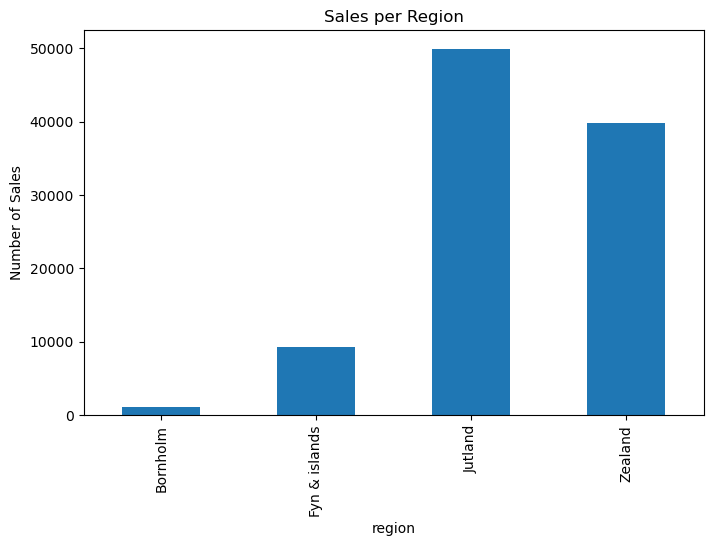

In [24]:
sales.plot(kind='bar', figsize=(8,5))

plt.title('Sales per Region')
plt.ylabel('Number of Sales')
plt.show()

In [25]:
compare = df.groupby('house_type')['sqm_price'].mean().sort_values(ascending=True)
compare

house_type
Villa         11,755.78
Farm          13,220.25
Summerhouse   14,943.21
Townhouse     18,752.62
Apartment     26,117.35
Name: sqm_price, dtype: float64

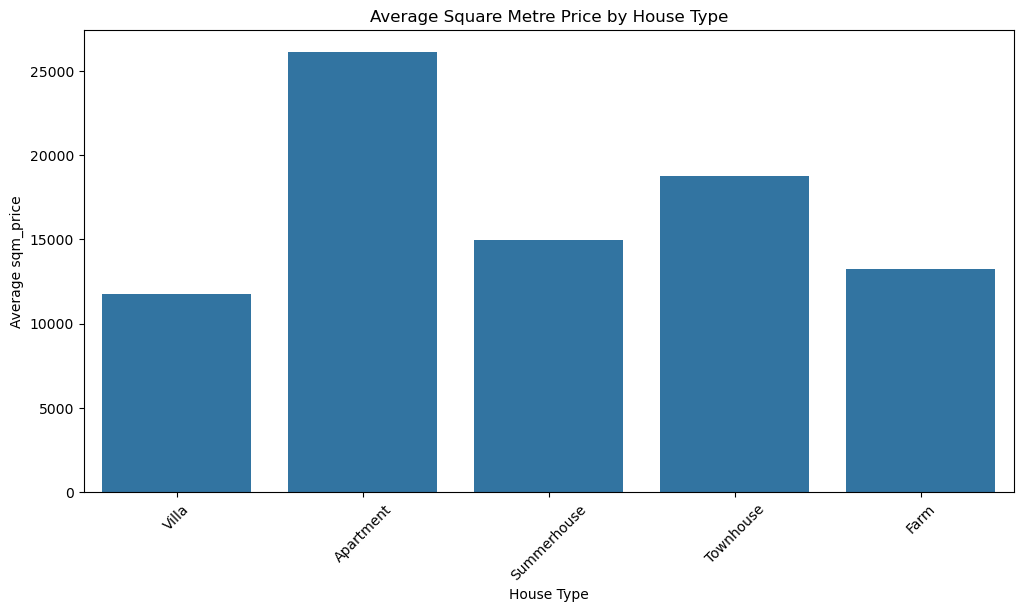

In [26]:
plt.figure(figsize=(12,6))

sb.barplot(data=df, x='house_type', y='sqm_price', errorbar=None)
plt.xticks(rotation=45)
plt.title('Average Square Metre Price by House Type')
plt.xlabel('House Type')
plt.ylabel('Average sqm_price')
plt.show()

In [27]:
comparison = df.groupby(['region','house_type'])['sqm_price'].mean().reset_index()
comp = df.pivot_table(
    values='sqm_price',
    index='house_type',
    columns='region',
    aggfunc='mean'
)
comp


region,Bornholm,Fyn & islands,Jutland,Zealand
house_type,,,,
Apartment,"20,909.12","23,322.55","23,332.54","28,661.84"
Farm,"9,635.41","11,821.46","12,610.29","15,904.17"
Summerhouse,"14,139.79","16,394.02","14,184.75","15,642.09"
Townhouse,"9,289.41","15,888.32","16,363.90","21,690.28"
Villa,"8,257.99","9,893.35","9,625.26","15,769.49"


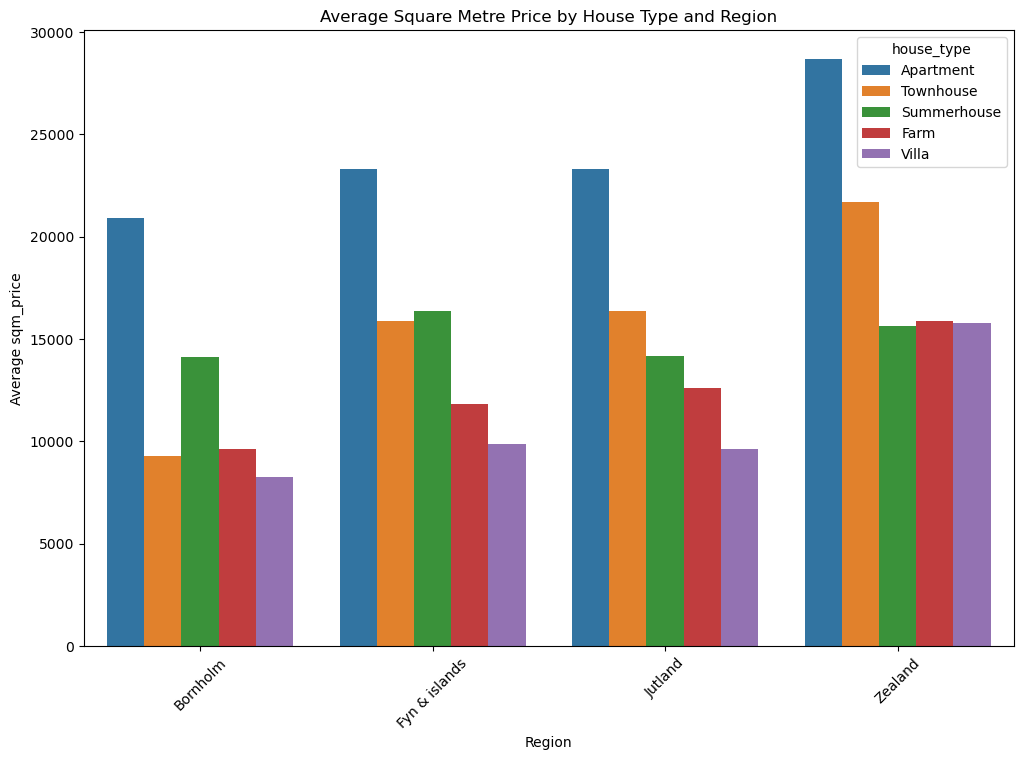

In [28]:
plt.figure(figsize=(12,8))
order=df.groupby('house_type')['sqm_price'].mean().sort_values(ascending=False).index
sb.barplot(data=comparison, x='region', y='sqm_price', hue='house_type', hue_order=order, errorbar=None)
plt.xticks(rotation=45)
plt.title('Average Square Metre Price by House Type and Region')
plt.xlabel('Region')
plt.ylabel('Average sqm_price')
plt.show()

In [29]:
df['area'].unique()

array(['Capital, Copenhagen', 'Other islands', 'North Zealand',
       'Fyn & islands', 'South jutland', 'East & mid jutland',
       'North jutland', 'Bornholm'], dtype=object)

In [30]:
selected=df[df['area'].isin(['Capital, Copenhagen', 'North Zealand', 'Other islands', 'East & mid jutland'])]
selected.groupby('area')['sqm_price'].mean().sort_values(ascending=False)

area
Capital, Copenhagen   26,996.56
North Zealand         18,882.33
East & mid jutland    15,625.84
Other islands         13,257.23
Name: sqm_price, dtype: float64

In [31]:
pd.crosstab(selected['area'], selected['house_type'])

house_type,Apartment,Farm,Summerhouse,Townhouse,Villa
area,,,,,
"Capital, Copenhagen",7434,36,141,2369,5808
East & mid jutland,3097,829,1233,1696,9524
North Zealand,933,148,1680,1062,3701
Other islands,1772,905,3089,1495,9167


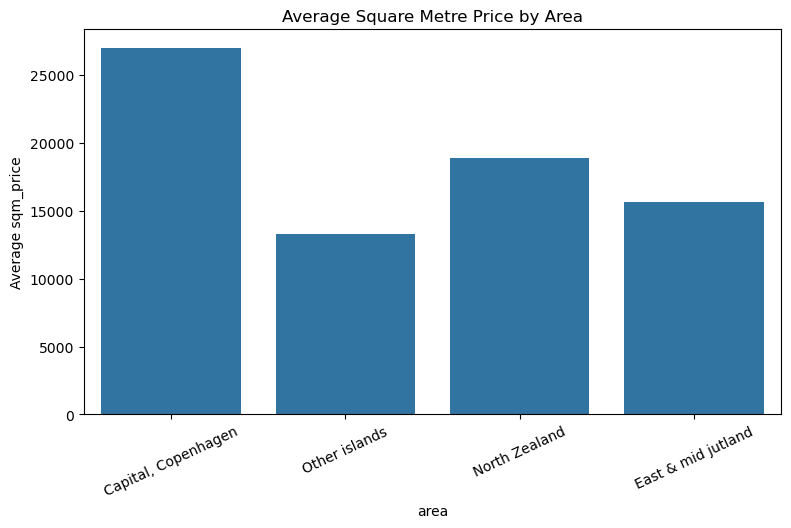

In [32]:
plt.figure(figsize=(9,5))
sb.barplot(data=selected, x='area', y='sqm_price', errorbar=None)
plt.xticks(rotation=25)
plt.title('Average Square Metre Price by Area')
plt.ylabel('Average sqm_price')
plt.show()

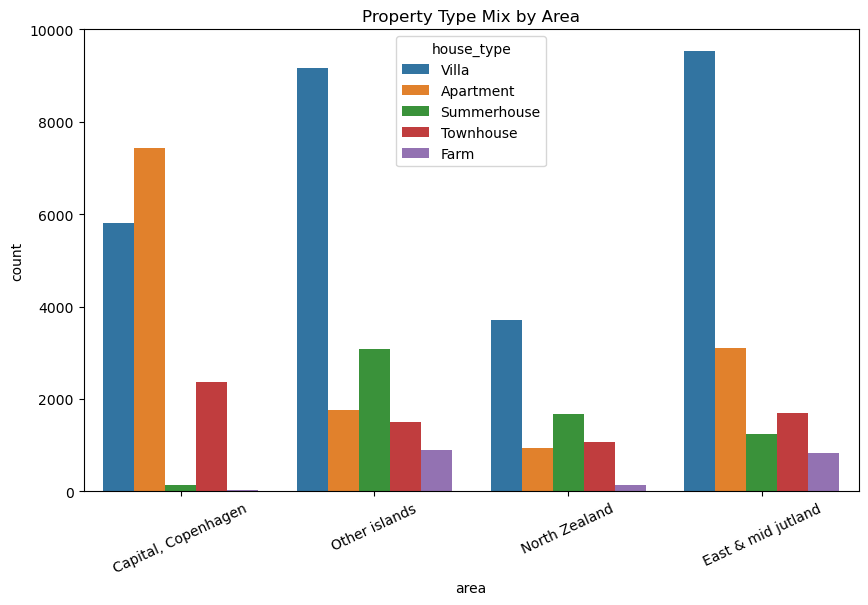

In [33]:
plt.figure(figsize=(10,6))
sb.countplot(data=selected, x='area', hue='house_type')
plt.xticks(rotation=25)
plt.title('Property Type Mix by Area')
plt.show()

In [34]:
q3_q4_2024=df[df['quarter'].isin(['2024Q3', '2024Q4'])]
avg_sqm=q3_q4_2024.groupby('quarter', observed=True)['sqm_price'].mean()
avg_sqm

quarter
2024Q3   21,084.27
2024Q4   20,345.63
Name: sqm_price, dtype: float64

In [35]:
sales=q3_q4_2024.groupby('quarter',observed=True).size()
sales

quarter
2024Q3    1209
2024Q4      77
dtype: int64

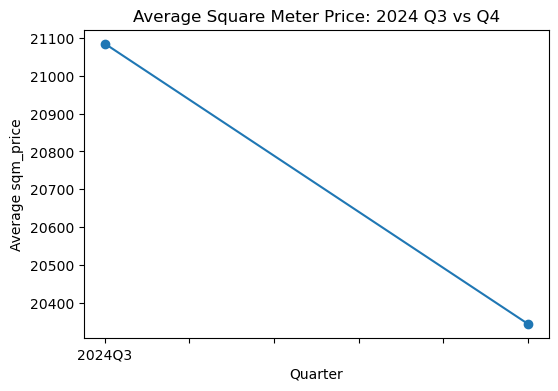

In [36]:
avg_sqm.plot(marker='o', figsize=(6,4))
plt.title('Average Square Meter Price: 2024 Q3 vs Q4')
plt.xlabel('Quarter')
plt.ylabel('Average sqm_price')
plt.show()

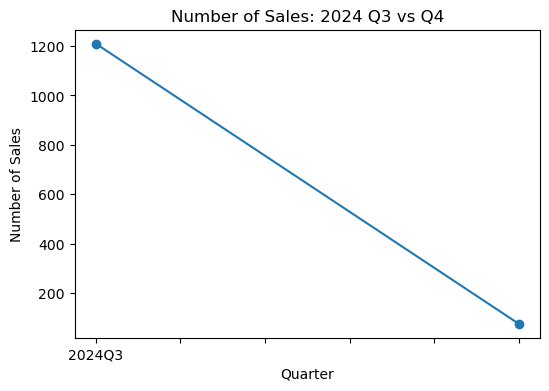

In [37]:
sales.plot(marker='o', figsize=(6,4))
plt.title('Number of Sales: 2024 Q3 vs Q4')
plt.xlabel('Quarter')
plt.ylabel('Number of Sales')
plt.show()

In [38]:
limit=df['purchase_price'].quantile(0.95)
top5=df[df['purchase_price']>=limit]
rest95=df[df['purchase_price']<limit]
print('Top 5%')
print(top5['sqm'].describe())
print('\nRemaining 95%')
print(rest95['sqm'].describe())

Top 5%
count   5,590.00
mean      165.74
std        55.26
min        67.00
25%       120.00
50%       158.00
75%       204.00
max       266.50
Name: sqm, dtype: float64

Remaining 95%
count   94,410.00
mean       125.88
std         50.74
min         26.00
25%         87.00
50%        121.00
75%        157.00
max        266.50
Name: sqm, dtype: float64


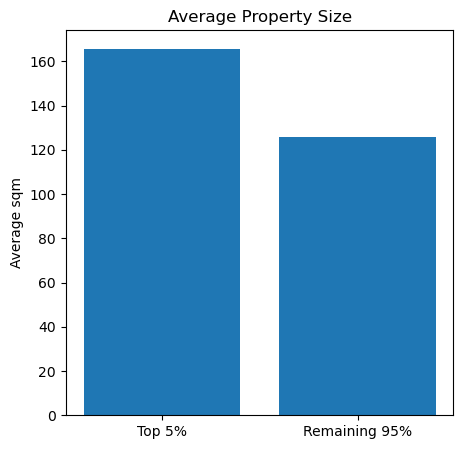

In [39]:
comparison={
    'Top 5%': top5['sqm'].mean(),
    'Remaining 95%': rest95['sqm'].mean()
}
plt.figure(figsize=(5,5))
plt.bar(comparison.keys(), comparison.values())
plt.title('Average Property Size')
plt.ylabel('Average sqm')
plt.show()

In [40]:
print('Top 5%')
print(top5['house_type'].value_counts())
print('\nRemaining 95%')
print(rest95['house_type'].value_counts())

Top 5%
house_type
Villa          2422
Apartment      1808
Farm            690
Townhouse       566
Summerhouse     104
Name: count, dtype: int64

Remaining 95%
house_type
Villa          51792
Apartment      17546
Summerhouse    11240
Townhouse       9618
Farm            4214
Name: count, dtype: int64


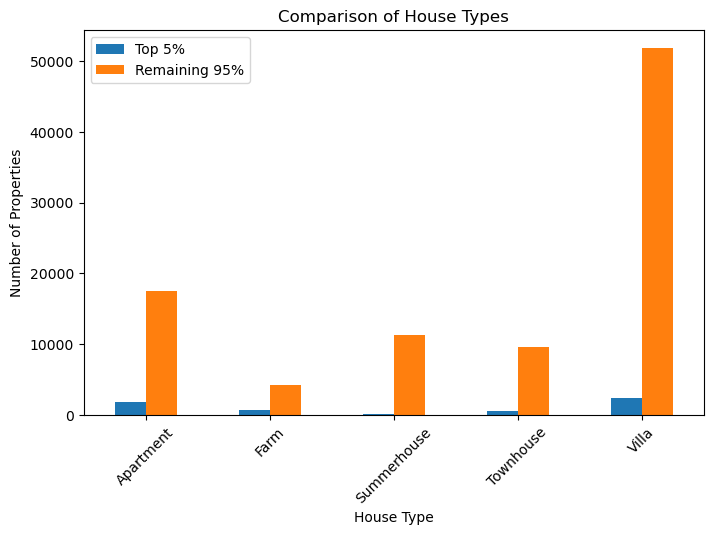

In [41]:
comparison = pd.DataFrame({
    'Top 5%': top5['house_type'].value_counts(),
    'Remaining 95%': rest95['house_type'].value_counts()
}).fillna(0)

comparison.plot(kind='bar', figsize=(8,5))

plt.title('Comparison of House Types')
plt.xlabel('House Type')
plt.ylabel('Number of Properties')
plt.xticks(rotation=45)
plt.legend(title='')
plt.show()

In [42]:
print('Top 5%')
print(top5['region'].value_counts())
print('\nRemaining 95%')
print(rest95['region'].value_counts())

Top 5%
region
Zealand          3625
Jutland          1658
Fyn & islands     287
Bornholm           20
Name: count, dtype: int64

Remaining 95%
region
Jutland          48279
Zealand          36115
Fyn & islands     8977
Bornholm          1039
Name: count, dtype: int64


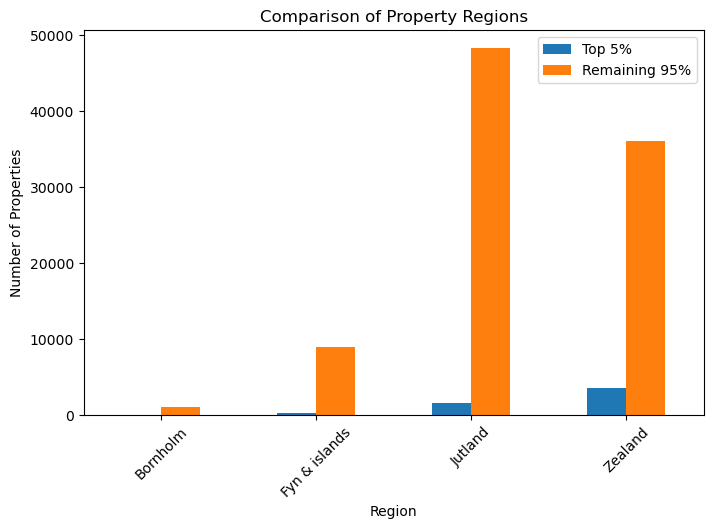

In [43]:
comparison = pd.DataFrame({
    'Top 5%': top5['region'].value_counts(),
    'Remaining 95%': rest95['region'].value_counts()
}).fillna(0)

comparison.plot(kind='bar', figsize=(8,5))

plt.title('Comparison of Property Regions')
plt.xlabel('Region')
plt.ylabel('Number of Properties')
plt.xticks(rotation=45)
plt.legend(title='')
plt.show()

In [44]:
print('Top 5%')
print(top5['area'].value_counts())
print('\nRemaining 95%')
print(rest95['area'].value_counts())

Top 5%
area
Capital, Copenhagen    2668
East & mid jutland      787
South jutland           575
North Zealand           506
Other islands           451
North jutland           296
Fyn & islands           287
Bornholm                 20
Name: count, dtype: int64

Remaining 95%
area
South jutland          21988
Other islands          15977
East & mid jutland     15592
Capital, Copenhagen    13120
North jutland          10699
Fyn & islands           8977
North Zealand           7018
Bornholm                1039
Name: count, dtype: int64


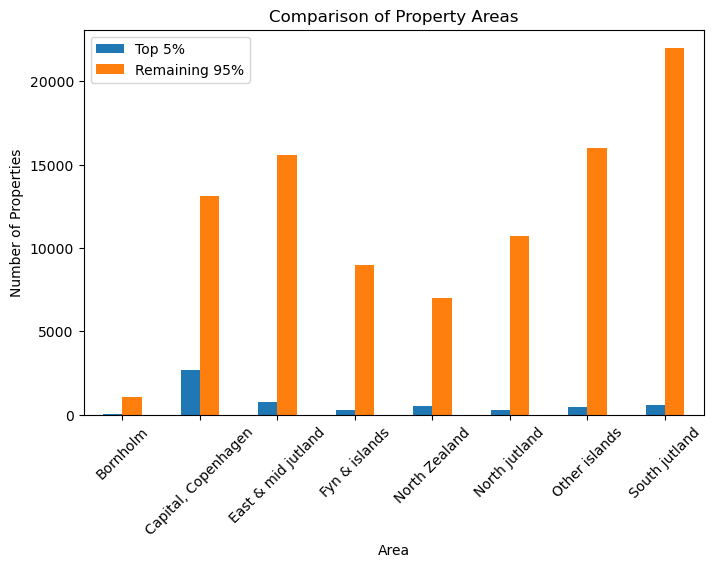

In [45]:
comparison = pd.DataFrame({
    'Top 5%': top5['area'].value_counts(),
    'Remaining 95%': rest95['area'].value_counts()
}).fillna(0)
comparison.plot(kind='bar', figsize=(8,5))

plt.title('Comparison of Property Areas')
plt.xlabel('Area')
plt.ylabel('Number of Properties')
plt.xticks(rotation=45)
plt.legend(title='')
plt.show()

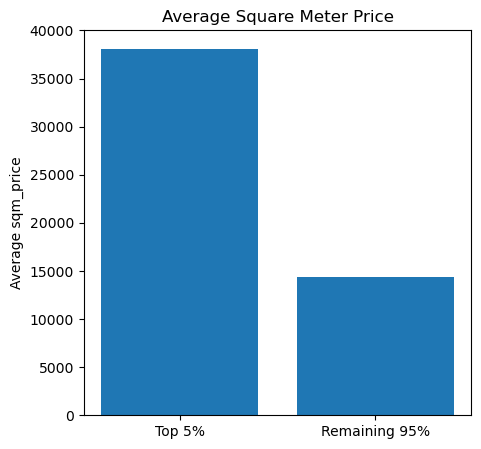

In [46]:
comparison={
    'Top 5%': top5['sqm_price'].mean(),
    'Remaining 95%': rest95['sqm_price'].mean()
}
plt.figure(figsize=(5,5))
plt.bar(comparison.keys(), comparison.values())
plt.title('Average Square Meter Price')
plt.ylabel('Average sqm_price')
plt.show()

In [47]:
c = df['house_type'].value_counts()
c

house_type
Villa          54214
Apartment      19354
Summerhouse    11344
Townhouse      10184
Farm            4904
Name: count, dtype: int64

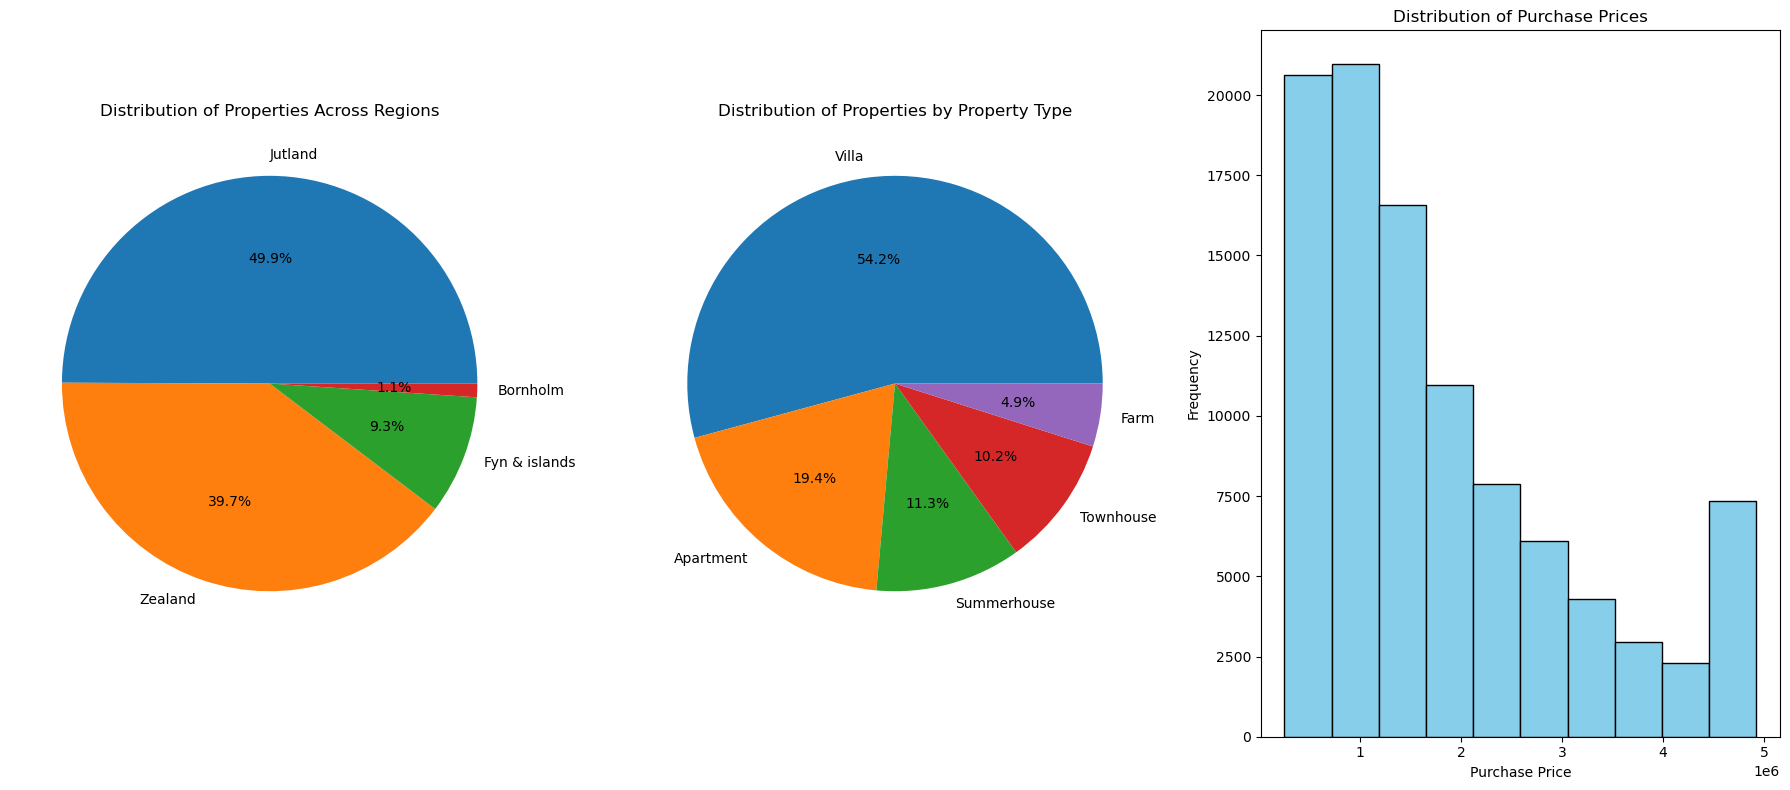

In [48]:
fig, ax = plt.subplots(1, 3, figsize=(18, 8))

df['region'].value_counts().plot(kind='pie', autopct='%1.1f%%',ax=ax[0])
ax[0].set_title('Distribution of Properties Across Regions')
ax[0].set_ylabel("")

df['house_type'].value_counts().plot(kind='pie', autopct='%1.1f%%', ax=ax[1])
ax[1].set_title('Distribution of Properties by Property Type')
ax[1].set_ylabel("")

ax[2].hist(df['purchase_price'], bins=10, color='skyblue', edgecolor='black')
ax[2].set_title('Distribution of Purchase Prices')
ax[2].set_xlabel('Purchase Price')
ax[2].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

C:\Users\USER\AppData\Local\Temp\ipykernel_1288\2685392616.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  price_trend = df.groupby("quarter")["purchase_price"].mean()


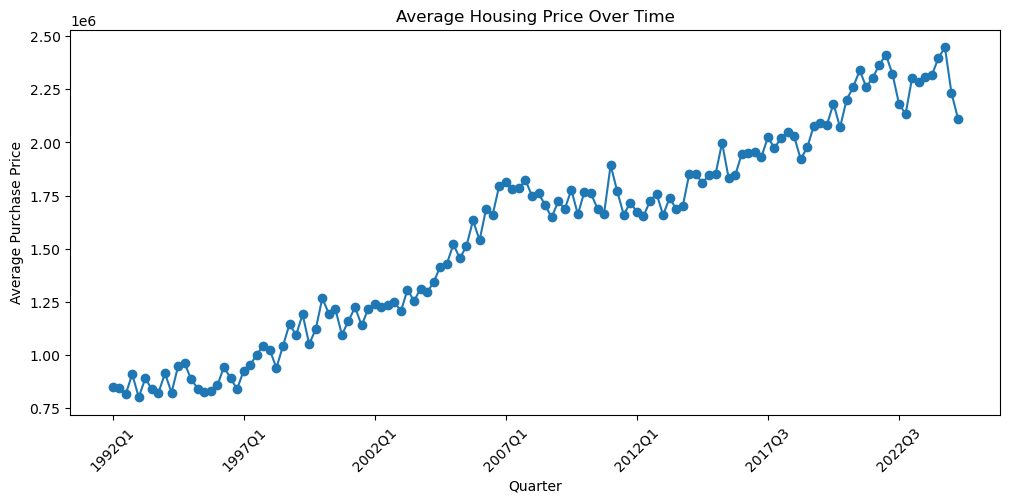

In [49]:
price_trend = df.groupby("quarter")["purchase_price"].mean()
plt.figure(figsize=(12,5))
price_trend.plot(marker="o")

plt.title("Average Housing Price Over Time")
plt.xlabel("Quarter")
plt.ylabel("Average Purchase Price")
plt.xticks(rotation=45)
plt.show()

C:\Users\USER\AppData\Local\Temp\ipykernel_1288\1337922758.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sales_trend = df.groupby("quarter").size()


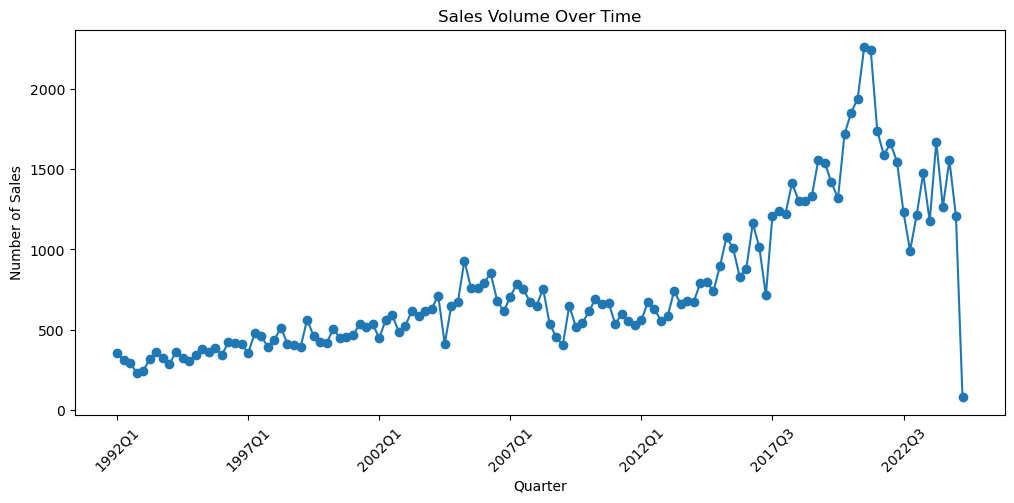

In [50]:
sales_trend = df.groupby("quarter").size()

plt.figure(figsize=(12,5))
sales_trend.plot(marker="o")

plt.title("Sales Volume Over Time")
plt.xlabel("Quarter")
plt.ylabel("Number of Sales")
plt.xticks(rotation=45)
plt.show()

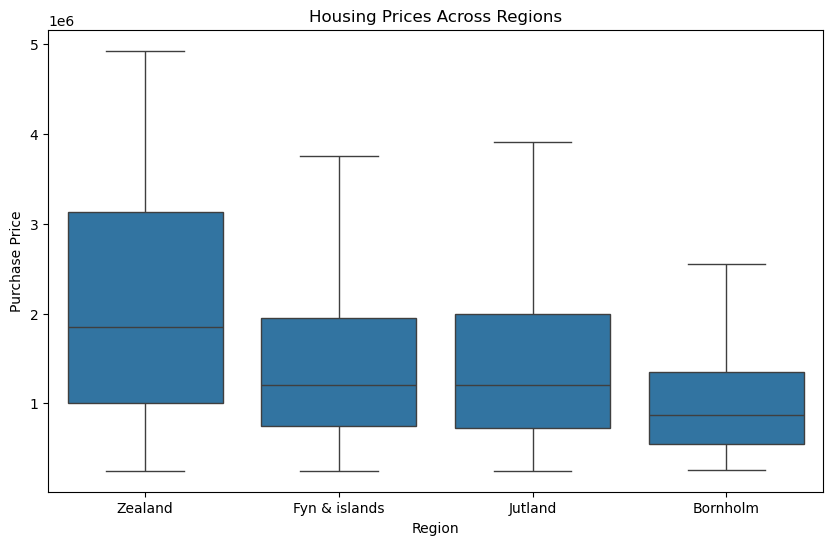

In [51]:
plt.figure(figsize=(10,6))

sb.boxplot(data=df, x="region", y="purchase_price", showfliers=False)

plt.title("Housing Prices Across Regions")
plt.xlabel("Region")
plt.ylabel("Purchase Price")
plt.show()

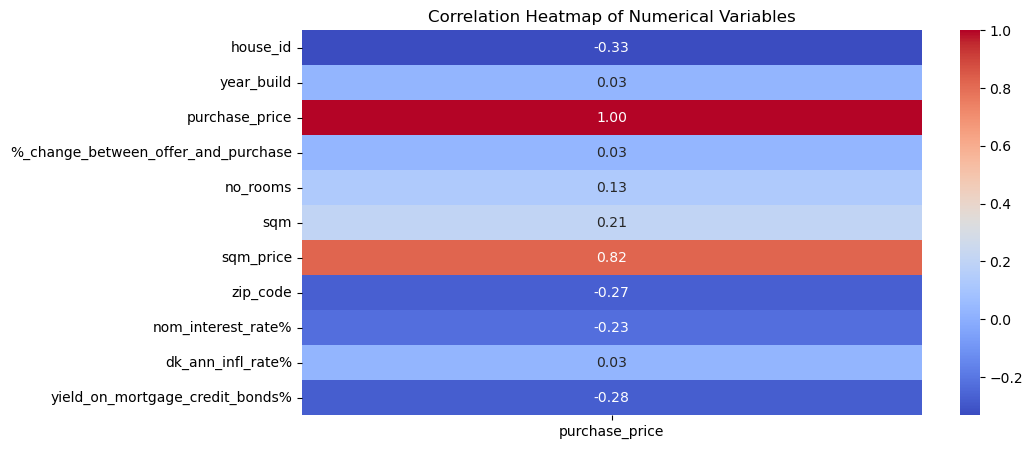

In [52]:
corr_price = df.corr(numeric_only=True)[['purchase_price']]
plt.figure(figsize=(10,5))
sb.heatmap(corr_price, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap of Numerical Variables")
plt.show()

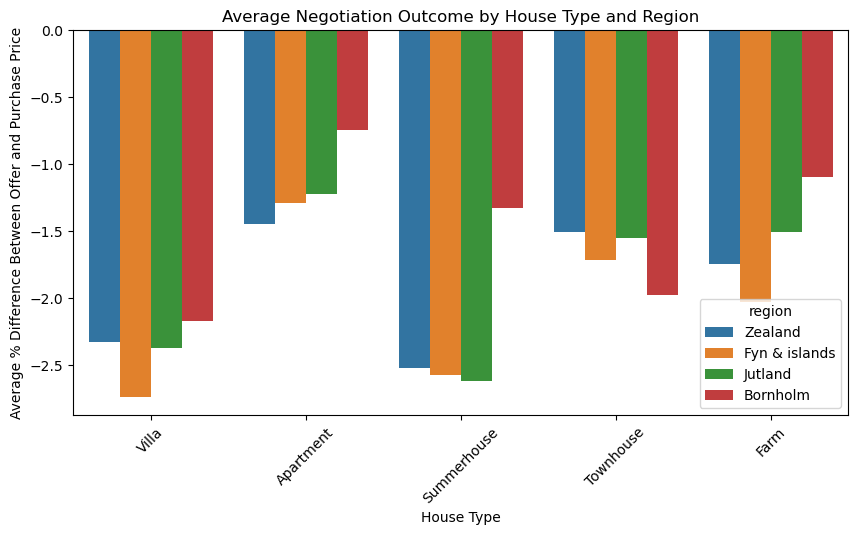

In [53]:
plt.figure(figsize=(10,5))
sb.barplot(data=df, x="house_type", y="%_change_between_offer_and_purchase", hue="region", errorbar=None)

plt.title("Average Negotiation Outcome by House Type and Region")
plt.xlabel("House Type")
plt.ylabel("Average % Difference Between Offer and Purchase Price")
plt.xticks(rotation=45)
plt.show()

C:\Users\USER\AppData\Local\Temp\ipykernel_1288\4020721249.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_price = df.groupby("age_group")["purchase_price"].mean()


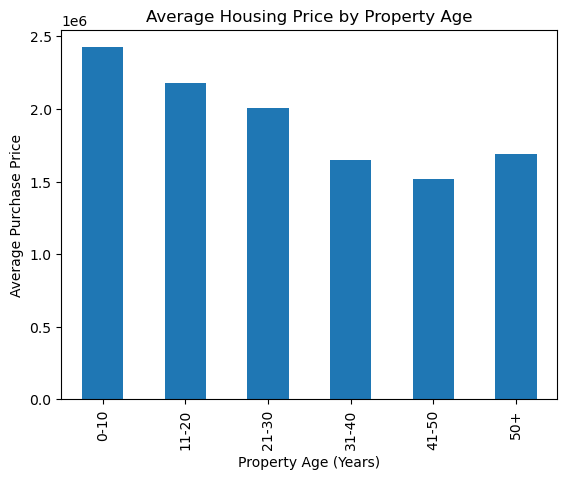

In [54]:
df["property_age"] = 2024 - df["year_build"]
bins = [0, 10, 20, 30, 40, 50, 100]
labels = ["0-10", "11-20", "21-30", "31-40", "41-50", "50+"]
df["age_group"] = pd.cut(df["property_age"], bins=bins, labels=labels)
age_price = df.groupby("age_group")["purchase_price"].mean()
age_price.plot(kind="bar")

plt.title("Average Housing Price by Property Age")
plt.xlabel("Property Age (Years)")
plt.ylabel("Average Purchase Price")
plt.show()


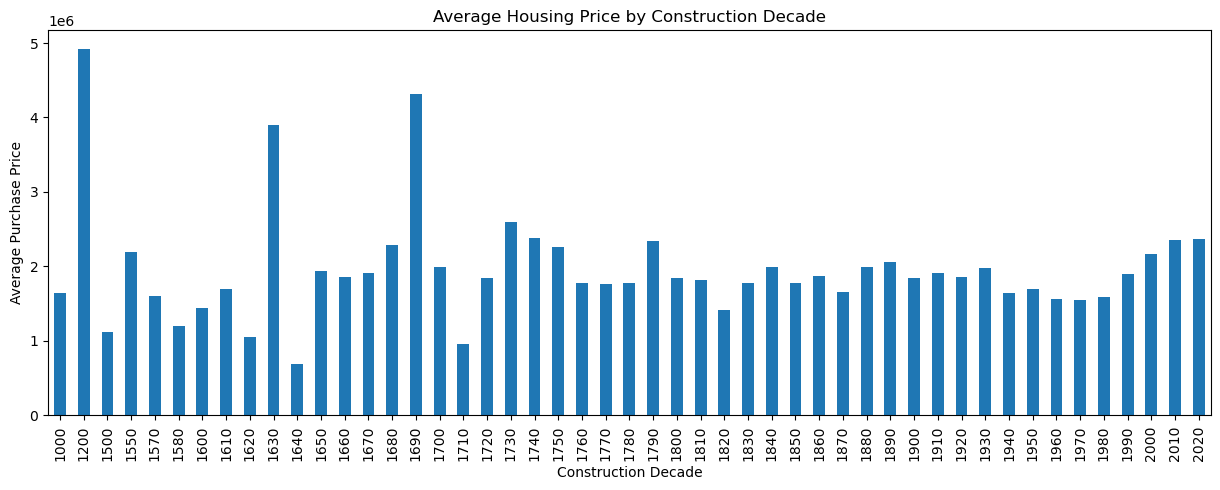

In [55]:
df["decade"] = (df["year_build"] // 10) * 10
decade_price = df.groupby("decade")["purchase_price"].mean().sort_index()
plt.figure(figsize=(15,5))
decade_price.plot(kind="bar")
plt.title("Average Housing Price by Construction Decade")
plt.xlabel("Construction Decade")
plt.ylabel("Average Purchase Price")
plt.show()